## Task 3

In [43]:
import torch 

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')



Using device: mps


In [44]:
import glob
images_paths = sorted(glob.glob("./data/UAVWasteDataset_subset/*"))
print(f'Found {len(images_paths)} images in the dataset.')

random_images = [images_paths[i] for i in torch.randperm(len(images_paths))[:10]]


Found 40 images in the dataset.


In [45]:
from ultralytics import YOLO
from transformers import pipeline, AutoImageProcessor

yolo_model = YOLO('yolo11m.pt').to(device)
detr_preprocessor = AutoImageProcessor.from_pretrained('facebook/detr-resnet-50')
detr_model = pipeline('object-detection', model='facebook/detr-resnet-50',device=device, use_fast=True)

rt_detr_preprocessor = AutoImageProcessor.from_pretrained('PekingU/rtdetr_r50vd')
rt_detr_model = pipeline('object-detection', model='PekingU/rtdetr_r50vd',device=device, use_fast=True)
pretrained_model = ...



Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps
Device set to use mps


In [46]:
def yolo_to_torchmetrics(yolo_results):
    yolo_boxes = yolo_results.boxes.xyxy
    return {
        "boxes": yolo_boxes,
        "scores": yolo_results.boxes.conf,
        "labels": torch.zeros(len(yolo_results.boxes.xyxy), dtype=torch.int64), # Ignoring class
    }

In [49]:
def evaluate_yolo_on_images(model, images):
    results = []
    for img_path in images:
        yolo_results = model(img_path)[0]
        converted = yolo_to_torchmetrics(yolo_results)
        results.append(converted)
    return results

def evaluate_hf_model_on_images(model, images):
    results = []
    for img_path in images:
        image = Image.open(img_path).convert("RGB")

        outputs = model(image)
        boxes = torch.tensor(
            [list(o["box"].values()) for o in outputs], dtype=torch.float32
        )
        scores = torch.tensor([o["score"] for o in outputs], dtype=torch.float32)
        labels = [o["label"] for o in outputs]
        results.append({
            "boxes": boxes,
            "scores": scores,
            "labels": labels,
        })
    return results

yolo_results = evaluate_yolo_on_images(yolo_model, random_images)
detr_results = evaluate_hf_model_on_images(detr_model, random_images)
rt_detr_results = evaluate_hf_model_on_images(rt_detr_model, random_images)


image 1/1 /Users/lucadavi/Documents/VisComp/VisComp2025/Assignment2/data/UAVWasteDataset_subset/BATCH_s03_img_1100.jpg: 288x640 (no detections), 356.9ms
Speed: 17.3ms preprocess, 356.9ms inference, 5.3ms postprocess per image at shape (1, 3, 288, 640)

image 1/1 /Users/lucadavi/Documents/VisComp/VisComp2025/Assignment2/data/UAVWasteDataset_subset/batch_s02_img_13.jpg: 288x640 1 person, 24.5ms
Speed: 1.9ms preprocess, 24.5ms inference, 11.4ms postprocess per image at shape (1, 3, 288, 640)

image 1/1 /Users/lucadavi/Documents/VisComp/VisComp2025/Assignment2/data/UAVWasteDataset_subset/BATCH_d06_img_2500.jpg: 384x640 (no detections), 337.4ms
Speed: 3.2ms preprocess, 337.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /Users/lucadavi/Documents/VisComp/VisComp2025/Assignment2/data/UAVWasteDataset_subset/photo_2020-10-23_14-02-02.jpg: 640x480 1 bench, 62.9ms
Speed: 1.5ms preprocess, 62.9ms inference, 4.2ms postprocess per image at shape (1, 3, 640, 480)

ima

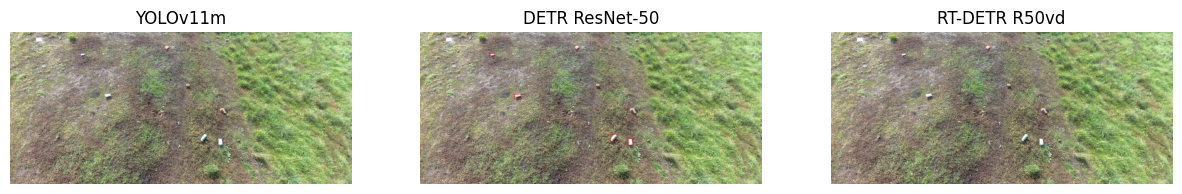

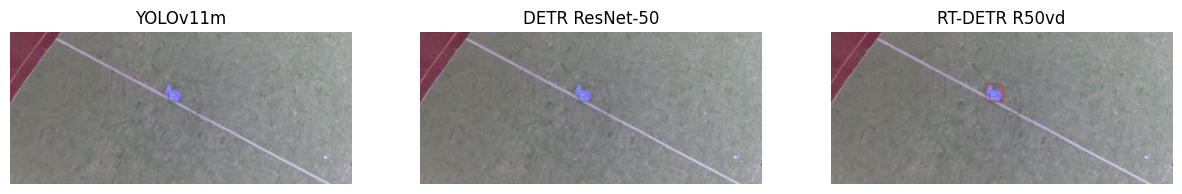

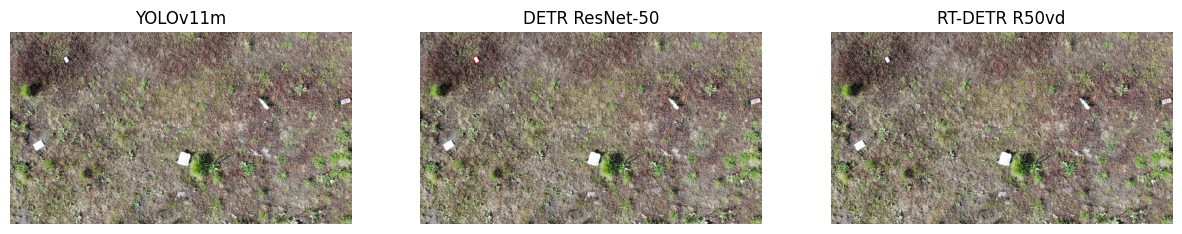

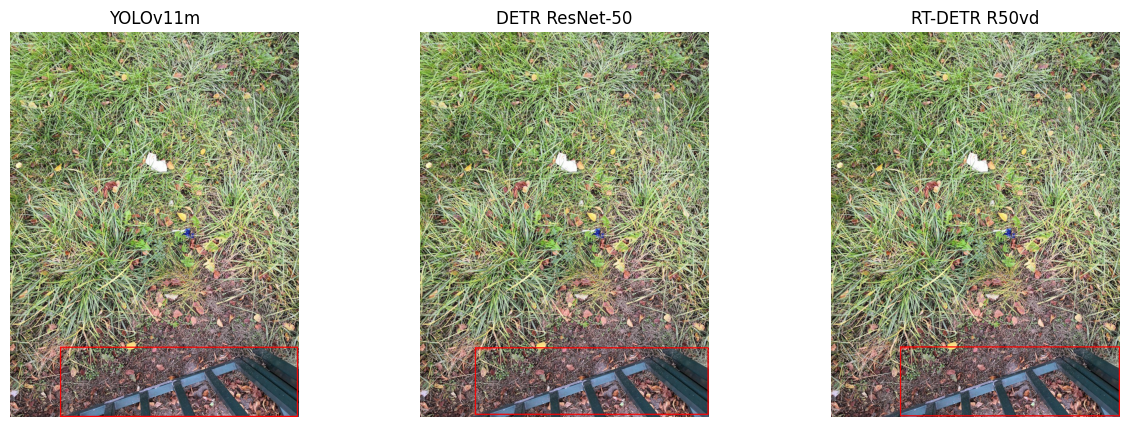

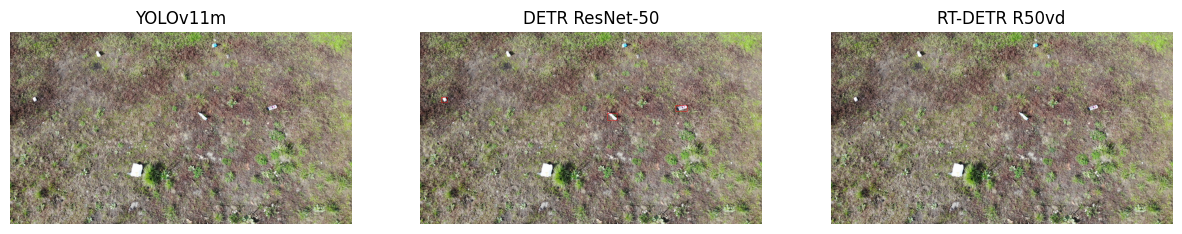

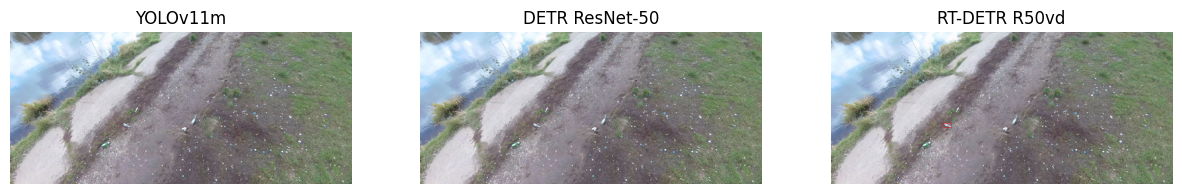

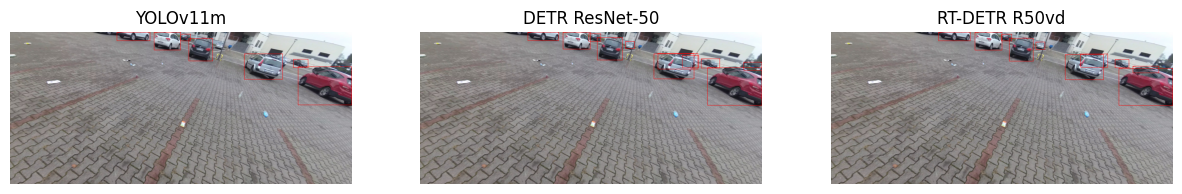

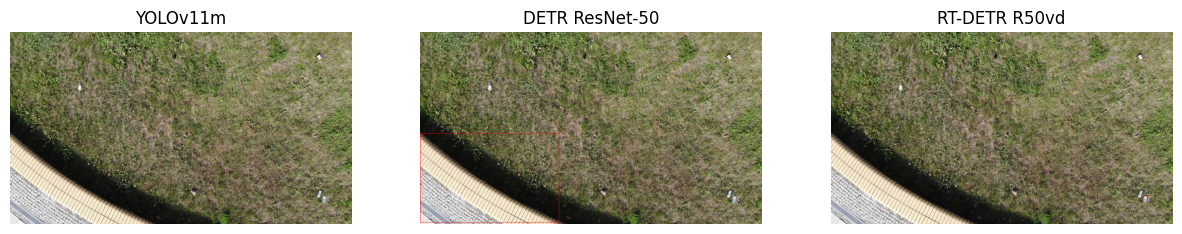

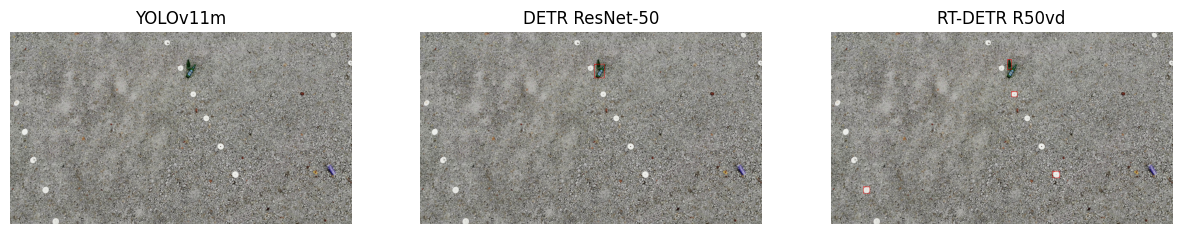

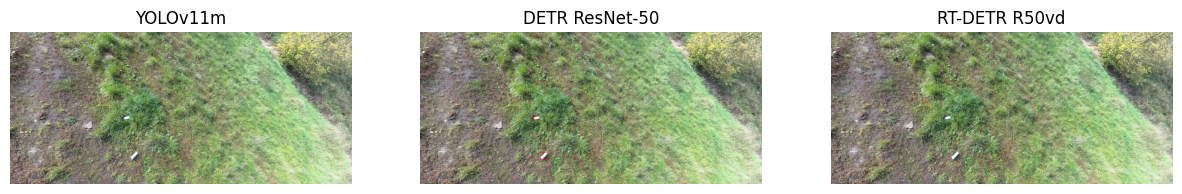

In [52]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

def draw_boxes(image_path, detections, threshold=0.5):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    for score, label, box in zip(detections['scores'], detections['labels'], detections['boxes']):
        if score >= threshold:
            x1, y1, x2, y2 = box.tolist()
            
            draw.rectangle([x1, y1, x2, y2], outline="red", width=4)
            draw.text((x1, y1), f"{label}: {score:.2f}", fill="red")
    return image

for i, img_path in enumerate(random_images):
    yolo_img = draw_boxes(img_path, yolo_results[i])
    detr_img = draw_boxes(img_path, detr_results[i])
    rt_detr_img = draw_boxes(img_path, rt_detr_results[i])
    
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.title("YOLOv11m")
    plt.imshow(yolo_img)
    plt.axis('off')
    
    plt.subplot(1,3,2)
    plt.title("DETR ResNet-50")
    plt.imshow(detr_img)
    plt.axis('off')
    
    plt.subplot(1,3,3)
    plt.title("RT-DETR R50vd")
    plt.imshow(rt_detr_img)
    plt.axis('off')
    
    plt.show()
